# Controller Analysis Final

This notebook explains the project pivot and evaluates the fixed-mode controller using Aman's measured benchmark results. The original idea was to switch modes between prefill and decode inside one request, but that broke the KV cache. The controller now reads static request features up front, picks one fixed mode, and keeps the whole request on that mode.

The quality target is simple. The controller passes if mean accuracy across the 5 auto-graded evals stays within 1.5 points of the FP16 baseline. What this notebook adds beyond Aman's pipeline is offline controller analysis using his measured data, plus oracle comparisons and explicit pass or fail framing.

## Inputs

These cells reuse the verified controller imports, the measured result tables, the workload features, and the small supplement list from the existing simulation notebook. The only data change here is a narrow memory-only patch for four missing `int8_quant` eval rows taken from the peak GPU memory heatmap.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from io import StringIO

import numpy as np
import pandas as pd
from controller import classify_request, route_request
from controller.features import RequestFeatures

try:
    import matplotlib.pyplot as plt
    PLOTTING_AVAILABLE = True
except Exception:
    plt = None
    PLOTTING_AVAILABLE = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
WORKLOADS = ['short_prompt_short_output',
 'short_prompt_long_output',
 'long_prompt_short_output',
 'long_prompt_long_output',
 'shared_prefix_chat_v0',
 'shared_prefix_chat_v1',
 'memory_pressure_long_context',
 'mmlu_pro_eval',
 'gsm8k_eval',
 'truthfulqa_eval',
 'gpqa_eval',
 'mlu_eval',
 'mt_bench_eval',
 'alpacaeval2_lc_eval']
THROUGHPUT_TPS = {'fp16_baseline': {'short_prompt_short_output': 45.6,
                   'short_prompt_long_output': 46.3,
                   'long_prompt_short_output': 41.5,
                   'long_prompt_long_output': 45.5,
                   'shared_prefix_chat_v0': 44.8,
                   'shared_prefix_chat_v1': 44.5,
                   'memory_pressure_long_context': 45.1,
                   'mmlu_pro_eval': 18.9,
                   'gsm8k_eval': 49.0,
                   'truthfulqa_eval': 22.1,
                   'gpqa_eval': 18.9,
                   'mlu_eval': 19.7,
                   'mt_bench_eval': 49.2,
                   'alpacaeval2_lc_eval': 49.3},
 'gptq_4bit': {'short_prompt_short_output': 116.8,
               'short_prompt_long_output': 136.3,
               'long_prompt_short_output': 91.7,
               'long_prompt_long_output': 123.9,
               'shared_prefix_chat_v0': 112.4,
               'shared_prefix_chat_v1': 111.1,
               'memory_pressure_long_context': 113.9,
               'mmlu_pro_eval': 16.6,
               'gsm8k_eval': 137.0,
               'truthfulqa_eval': 18.6,
               'gpqa_eval': 16.3,
               'mlu_eval': 17.0,
               'mt_bench_eval': 140.4,
               'alpacaeval2_lc_eval': 138.6},
 'speculative_decoding': {'short_prompt_short_output': 100.0,
                          'short_prompt_long_output': 98.2,
                          'long_prompt_short_output': 75.6,
                          'long_prompt_long_output': 107.0,
                          'shared_prefix_chat_v0': 85.8,
                          'shared_prefix_chat_v1': 85.6,
                          'memory_pressure_long_context': 71.8,
                          'mmlu_pro_eval': 12.7,
                          'gsm8k_eval': 123.9,
                          'truthfulqa_eval': 14.3,
                          'gpqa_eval': 12.8,
                          'mlu_eval': 13.2,
                          'mt_bench_eval': 111.0,
                          'alpacaeval2_lc_eval': 107.9},
 'gptq_plus_prefix_caching': {'short_prompt_short_output': 127.9,
                              'short_prompt_long_output': 139.5,
                              'long_prompt_short_output': 122.1,
                              'long_prompt_long_output': 134.1,
                              'shared_prefix_chat_v0': 129.3,
                              'shared_prefix_chat_v1': 130.2,
                              'memory_pressure_long_context': 129.5},
 'int8_plus_continuous_batching': {'short_prompt_short_output': 309.9,
                                   'short_prompt_long_output': 221.6,
                                   'long_prompt_short_output': 192.4,
                                   'long_prompt_long_output': 283.4,
                                   'shared_prefix_chat_v0': 251.8,
                                   'shared_prefix_chat_v1': 246.9,
                                   'memory_pressure_long_context': 244.3},
 'prefix_caching': {'short_prompt_short_output': 65.0,
                    'short_prompt_long_output': 67.7,
                    'long_prompt_short_output': 63.0,
                    'long_prompt_long_output': 66.7,
                    'shared_prefix_chat_v0': 65.5,
                    'shared_prefix_chat_v1': 65.6,
                    'memory_pressure_long_context': 65.1,
                    'mmlu_pro_eval': 17.0,
                    'gsm8k_eval': 67.4,
                    'truthfulqa_eval': 19.0,
                    'gpqa_eval': 17.0,
                    'mlu_eval': 17.7,
                    'mt_bench_eval': 67.7,
                    'alpacaeval2_lc_eval': 67.0},
 'continuous_batching': {'short_prompt_short_output': 230.6,
                         'short_prompt_long_output': 184.4,
                         'long_prompt_short_output': 140.1,
                         'long_prompt_long_output': 211.0,
                         'shared_prefix_chat_v0': 185.4,
                         'shared_prefix_chat_v1': 182.2,
                         'memory_pressure_long_context': 181.9}}
LATENCY_MS = {'fp16_baseline': {'short_prompt_short_output': 702.0,
                   'short_prompt_long_output': 2762.0,
                   'long_prompt_short_output': 772.0,
                   'long_prompt_long_output': 2814.0,
                   'shared_prefix_chat_v0': 1428.0,
                   'shared_prefix_chat_v1': 1439.0,
                   'memory_pressure_long_context': 2839.0,
                   'mmlu_pro_eval': 54.0,
                   'gsm8k_eval': 3131.0,
                   'truthfulqa_eval': 45.0,
                   'gpqa_eval': 54.0,
                   'mlu_eval': 52.0,
                   'mt_bench_eval': 9571.0,
                   'alpacaeval2_lc_eval': 7580.0},
 'gptq_4bit': {'short_prompt_short_output': 283.0,
               'short_prompt_long_output': 939.0,
               'long_prompt_short_output': 349.0,
               'long_prompt_long_output': 1034.0,
               'shared_prefix_chat_v0': 569.0,
               'shared_prefix_chat_v1': 576.0,
               'memory_pressure_long_context': 1124.0,
               'mmlu_pro_eval': 63.0,
               'gsm8k_eval': 1086.0,
               'truthfulqa_eval': 54.0,
               'gpqa_eval': 62.0,
               'mlu_eval': 60.0,
               'mt_bench_eval': 3129.0,
               'alpacaeval2_lc_eval': 2512.0},
 'speculative_decoding': {'short_prompt_short_output': 320.0,
                          'short_prompt_long_output': 1304.0,
                          'long_prompt_short_output': 423.0,
                          'long_prompt_long_output': 1197.0,
                          'shared_prefix_chat_v0': 746.0,
                          'shared_prefix_chat_v1': 748.0,
                          'memory_pressure_long_context': 1784.0,
                          'mmlu_pro_eval': 80.0,
                          'gsm8k_eval': 1242.0,
                          'truthfulqa_eval': 70.0,
                          'gpqa_eval': 79.0,
                          'mlu_eval': 77.0,
                          'mt_bench_eval': 4237.0,
                          'alpacaeval2_lc_eval': 3443.0},
 'gptq_plus_prefix_caching': {'short_prompt_short_output': 252.0,
                              'short_prompt_long_output': 917.0,
                              'long_prompt_short_output': 264.0,
                              'long_prompt_long_output': 954.0,
                              'shared_prefix_chat_v0': 496.0,
                              'shared_prefix_chat_v1': 492.0,
                              'memory_pressure_long_context': 990.0},
 'int8_plus_continuous_batching': {'short_prompt_short_output': 413.0,
                                   'short_prompt_long_output': 1458.0,
                                   'long_prompt_short_output': 665.0,
                                   'long_prompt_long_output': 1807.0,
                                   'shared_prefix_chat_v0': 1017.0,
                                   'shared_prefix_chat_v1': 1037.0,
                                   'memory_pressure_long_context': 2096.0},
 'prefix_caching': {'short_prompt_short_output': 492.0,
                    'short_prompt_long_output': 1892.0,
                    'long_prompt_short_output': 509.0,
                    'long_prompt_long_output': 1919.0,
                    'shared_prefix_chat_v0': 977.0,
                    'shared_prefix_chat_v1': 976.0,
                    'memory_pressure_long_context': 1967.0,
                    'mmlu_pro_eval': 60.0,
                    'gsm8k_eval': 2251.0,
                    'truthfulqa_eval': 53.0,
                    'gpqa_eval': 60.0,
                    'mlu_eval': 58.0,
                    'mt_bench_eval': 6997.0,
                    'alpacaeval2_lc_eval': 5561.0},
 'continuous_batching': {'short_prompt_short_output': 555.0,
                         'short_prompt_long_output': 1979.0,
                         'long_prompt_short_output': 914.0,
                         'long_prompt_long_output': 2426.0,
                         'shared_prefix_chat_v0': 1381.0,
                         'shared_prefix_chat_v1': 1405.0,
                         'memory_pressure_long_context': 2815.0}}
ENERGY_J_PER_TOKEN = {'fp16_baseline': {'short_prompt_short_output': 3.91,
                   'short_prompt_long_output': 3.88,
                   'long_prompt_short_output': 5.05,
                   'long_prompt_long_output': 4.21,
                   'shared_prefix_chat_v0': 4.67,
                   'shared_prefix_chat_v1': 4.71,
                   'memory_pressure_long_context': 4.41,
                   'mmlu_pro_eval': 8.22,
                   'gsm8k_eval': 3.82,
                   'truthfulqa_eval': 8.38,
                   'gpqa_eval': 9.88,
                   'mlu_eval': 7.95,
                   'mt_bench_eval': 3.85,
                   'alpacaeval2_lc_eval': 3.82},
 'gptq_4bit': {'short_prompt_short_output': 1.81,
               'short_prompt_long_output': 1.5,
               'long_prompt_short_output': 2.73,
               'long_prompt_long_output': 1.86,
               'shared_prefix_chat_v0': 2.37,
               'shared_prefix_chat_v1': 2.42,
               'memory_pressure_long_context': 2.06,
               'mmlu_pro_eval': 7.53,
               'gsm8k_eval': 1.48,
               'truthfulqa_eval': 9.77,
               'gpqa_eval': 9.87,
               'mlu_eval': 8.29,
               'mt_bench_eval': 1.48,
               'alpacaeval2_lc_eval': 1.53},
 'speculative_decoding': {'short_prompt_short_output': 1.88,
                          'short_prompt_long_output': 2.02,
                          'long_prompt_short_output': 3.12,
                          'long_prompt_long_output': 2.01,
                          'shared_prefix_chat_v0': 2.91,
                          'shared_prefix_chat_v1': 2.95,
                          'memory_pressure_long_context': 3.08,
                          'mmlu_pro_eval': 7.69,
                          'gsm8k_eval': 1.6,
                          'truthfulqa_eval': 8.79,
                          'gpqa_eval': 9.24,
                          'mlu_eval': 7.94,
                          'mt_bench_eval': 1.88,
                          'alpacaeval2_lc_eval': 1.92},
 'gptq_plus_prefix_caching': {'short_prompt_short_output': 1.18,
                              'short_prompt_long_output': 1.4,
                              'long_prompt_short_output': 1.43,
                              'long_prompt_long_output': 1.42,
                              'shared_prefix_chat_v0': 1.4,
                              'shared_prefix_chat_v1': 1.35,
                              'memory_pressure_long_context': 1.45},
 'int8_plus_continuous_batching': {'short_prompt_short_output': 0.62,
                                   'short_prompt_long_output': 0.85,
                                   'long_prompt_short_output': 1.37,
                                   'long_prompt_long_output': 0.77,
                                   'shared_prefix_chat_v0': 1.04,
                                   'shared_prefix_chat_v1': 1.05,
                                   'memory_pressure_long_context': 0.98},
 'prefix_caching': {'short_prompt_short_output': 3.13,
                    'short_prompt_long_output': 3.38,
                    'long_prompt_short_output': 3.49,
                    'long_prompt_long_output': 3.47,
                    'shared_prefix_chat_v0': 3.43,
                    'shared_prefix_chat_v1': 3.44,
                    'memory_pressure_long_context': 3.5,
                    'mmlu_pro_eval': 7.4,
                    'gsm8k_eval': 3.43,
                    'truthfulqa_eval': 9.07,
                    'gpqa_eval': 9.48,
                    'mlu_eval': 8.07,
                    'mt_bench_eval': 3.46,
                    'alpacaeval2_lc_eval': 3.46},
 'continuous_batching': {'short_prompt_short_output': 1.05,
                         'short_prompt_long_output': 1.28,
                         'long_prompt_short_output': 2.13,
                         'long_prompt_long_output': 1.26,
                         'shared_prefix_chat_v0': 1.54,
                         'shared_prefix_chat_v1': 1.61,
                         'memory_pressure_long_context': 1.54}}
PEAK_GPU_MEMORY_MB = {'fp16_baseline': {'short_prompt_short_output': 32673.0,
                   'short_prompt_long_output': 32676.0,
                   'long_prompt_short_output': 32812.0,
                   'long_prompt_long_output': 32812.0,
                   'shared_prefix_chat_v0': 32809.0,
                   'shared_prefix_chat_v1': 32806.0,
                   'memory_pressure_long_context': 36817.0,
                   'mmlu_pro_eval': 32686.0,
                   'gsm8k_eval': 32670.0,
                   'truthfulqa_eval': 32672.0,
                   'gpqa_eval': 32687.0,
                   'mlu_eval': 32682.0,
                   'mt_bench_eval': 32669.0,
                   'alpacaeval2_lc_eval': 32661.0},
 'gptq_4bit': {'short_prompt_short_output': 32978.0,
               'short_prompt_long_output': 32978.0,
               'long_prompt_short_output': 33078.0,
               'long_prompt_long_output': 33078.0,
               'shared_prefix_chat_v0': 33075.0,
               'shared_prefix_chat_v1': 33073.0,
               'memory_pressure_long_context': 37013.0,
               'mmlu_pro_eval': 32986.0,
               'gsm8k_eval': 32974.0,
               'truthfulqa_eval': 32975.0,
               'gpqa_eval': 32986.0,
               'mlu_eval': 32983.0,
               'mt_bench_eval': 32974.0,
               'alpacaeval2_lc_eval': 32968.0},
 'speculative_decoding': {'short_prompt_short_output': 32861.0,
                          'short_prompt_long_output': 32861.0,
                          'long_prompt_short_output': 32998.0,
                          'long_prompt_long_output': 32998.0,
                          'shared_prefix_chat_v0': 32995.0,
                          'shared_prefix_chat_v1': 32992.0,
                          'memory_pressure_long_context': 36910.0,
                          'mmlu_pro_eval': 32872.0,
                          'gsm8k_eval': 32861.0,
                          'truthfulqa_eval': 32861.0,
                          'gpqa_eval': 32873.0,
                          'mlu_eval': 32870.0,
                          'mt_bench_eval': 32863.0,
                          'alpacaeval2_lc_eval': 32861.0},
 'gptq_plus_prefix_caching': {'short_prompt_short_output': 33006.0,
                              'short_prompt_long_output': 33005.0,
                              'long_prompt_short_output': 33010.0,
                              'long_prompt_long_output': 33005.0,
                              'shared_prefix_chat_v0': 33011.0,
                              'shared_prefix_chat_v1': 33010.0,
                              'memory_pressure_long_context': 36845.0},
 'int8_plus_continuous_batching': {'short_prompt_short_output': 32965.0,
                                   'short_prompt_long_output': 32965.0,
                                   'long_prompt_short_output': 33187.0,
                                   'long_prompt_long_output': 33187.0,
                                   'shared_prefix_chat_v0': 33181.0,
                                   'shared_prefix_chat_v1': 33172.0,
                                   'memory_pressure_long_context': 36925.0},
 'prefix_caching': {'short_prompt_short_output': 32937.0,
                    'short_prompt_long_output': 32936.0,
                    'long_prompt_short_output': 32943.0,
                    'long_prompt_long_output': 32936.0,
                    'shared_prefix_chat_v0': 32943.0,
                    'shared_prefix_chat_v1': 32943.0,
                    'memory_pressure_long_context': 36703.0,
                    'mmlu_pro_eval': 32961.0,
                    'gsm8k_eval': 32946.0,
                    'truthfulqa_eval': 32947.0,
                    'gpqa_eval': 32962.0,
                    'mlu_eval': 32957.0,
                    'mt_bench_eval': 32946.0,
                    'alpacaeval2_lc_eval': 32938.0},
 'continuous_batching': {'short_prompt_short_output': 33038.0,
                         'short_prompt_long_output': 33038.0,
                         'long_prompt_short_output': 33262.0,
                         'long_prompt_long_output': 33262.0,
                         'shared_prefix_chat_v0': 33256.0,
                         'shared_prefix_chat_v1': 33247.0,
                         'memory_pressure_long_context': 36963.0}}
PREFILL_SHARE_PCT = {'fp16_baseline': {'short_prompt_short_output': 3.7,
                   'short_prompt_long_output': 0.9,
                   'long_prompt_short_output': 14.2,
                   'long_prompt_long_output': 3.9,
                   'shared_prefix_chat_v0': 7.2,
                   'shared_prefix_chat_v1': 7.4,
                   'memory_pressure_long_context': 6.1,
                   'mmlu_pro_eval': 60.2,
                   'gsm8k_eval': 0.8,
                   'truthfulqa_eval': 54.9,
                   'gpqa_eval': 61.4,
                   'mlu_eval': 59.9,
                   'mt_bench_eval': 0.3,
                   'alpacaeval2_lc_eval': 0.3},
 'gptq_4bit': {'short_prompt_short_output': 17.4,
               'short_prompt_long_output': 5.2,
               'long_prompt_short_output': 36.3,
               'long_prompt_long_output': 12.2,
               'shared_prefix_chat_v0': 20.9,
               'shared_prefix_chat_v1': 21.9,
               'memory_pressure_long_context': 17.1,
               'mmlu_pro_eval': 88.0,
               'gsm8k_eval': 4.3,
               'truthfulqa_eval': 86.8,
               'gpqa_eval': 88.6,
               'mlu_eval': 88.1,
               'mt_bench_eval': 1.5,
               'alpacaeval2_lc_eval': 1.8},
 'speculative_decoding': {'short_prompt_short_output': 11.6,
                          'short_prompt_long_output': 2.8,
                          'long_prompt_short_output': 30.7,
                          'long_prompt_long_output': 10.9,
                          'shared_prefix_chat_v0': 16.4,
                          'shared_prefix_chat_v1': 17.0,
                          'memory_pressure_long_context': 11.5,
                          'mmlu_pro_eval': 55.2,
                          'gsm8k_eval': 2.9,
                          'truthfulqa_eval': 49.9,
                          'gpqa_eval': 55.5,
                          'mlu_eval': 54.0,
                          'mt_bench_eval': 0.8,
                          'alpacaeval2_lc_eval': 1.0},
 'gptq_plus_prefix_caching': {'short_prompt_short_output': 13.8,
                              'short_prompt_long_output': 3.2,
                              'long_prompt_short_output': 14.8,
                              'long_prompt_long_output': 3.5,
                              'shared_prefix_chat_v0': 7.6,
                              'shared_prefix_chat_v1': 7.5,
                              'memory_pressure_long_context': 4.6},
 'int8_plus_continuous_batching': {'short_prompt_short_output': 15.1,
                                   'short_prompt_long_output': 4.3,
                                   'long_prompt_short_output': 43.1,
                                   'long_prompt_long_output': 15.9,
                                   'shared_prefix_chat_v0': 25.8,
                                   'shared_prefix_chat_v1': 26.3,
                                   'memory_pressure_long_context': 13.1},
 'prefix_caching': {'short_prompt_short_output': 7.7,
                    'short_prompt_long_output': 2.0,
                    'long_prompt_short_output': 9.0,
                    'long_prompt_long_output': 2.2,
                    'shared_prefix_chat_v0': 4.6,
                    'shared_prefix_chat_v1': 4.6,
                    'memory_pressure_long_context': 2.7,
                    'mmlu_pro_eval': 75.1,
                    'gsm8k_eval': 1.7,
                    'truthfulqa_eval': 72.2,
                    'gpqa_eval': 75.4,
                    'mlu_eval': 74.6,
                    'mt_bench_eval': 0.5,
                    'alpacaeval2_lc_eval': 0.7},
 'continuous_batching': {'short_prompt_short_output': 15.4,
                         'short_prompt_long_output': 4.3,
                         'long_prompt_short_output': 45.3,
                         'long_prompt_long_output': 17.1,
                         'shared_prefix_chat_v0': 27.6,
                         'shared_prefix_chat_v1': 28.8,
                         'memory_pressure_long_context': 13.8}}
DECODE_SHARE_PCT = {'fp16_baseline': {'short_prompt_short_output': 96.3,
                   'short_prompt_long_output': 99.1,
                   'long_prompt_short_output': 85.8,
                   'long_prompt_long_output': 96.1,
                   'shared_prefix_chat_v0': 92.8,
                   'shared_prefix_chat_v1': 92.6,
                   'memory_pressure_long_context': 93.9,
                   'mmlu_pro_eval': 39.8,
                   'gsm8k_eval': 99.2,
                   'truthfulqa_eval': 45.1,
                   'gpqa_eval': 38.6,
                   'mlu_eval': 40.1,
                   'mt_bench_eval': 99.7,
                   'alpacaeval2_lc_eval': 99.7},
 'gptq_4bit': {'short_prompt_short_output': 82.6,
               'short_prompt_long_output': 94.8,
               'long_prompt_short_output': 63.7,
               'long_prompt_long_output': 87.8,
               'shared_prefix_chat_v0': 79.1,
               'shared_prefix_chat_v1': 78.1,
               'memory_pressure_long_context': 82.9,
               'mmlu_pro_eval': 12.0,
               'gsm8k_eval': 95.7,
               'truthfulqa_eval': 13.2,
               'gpqa_eval': 11.4,
               'mlu_eval': 11.9,
               'mt_bench_eval': 98.5,
               'alpacaeval2_lc_eval': 98.2},
 'speculative_decoding': {'short_prompt_short_output': 88.4,
                          'short_prompt_long_output': 97.2,
                          'long_prompt_short_output': 69.3,
                          'long_prompt_long_output': 89.1,
                          'shared_prefix_chat_v0': 83.6,
                          'shared_prefix_chat_v1': 83.0,
                          'memory_pressure_long_context': 88.5,
                          'mmlu_pro_eval': 44.8,
                          'gsm8k_eval': 97.1,
                          'truthfulqa_eval': 50.1,
                          'gpqa_eval': 44.5,
                          'mlu_eval': 46.0,
                          'mt_bench_eval': 99.2,
                          'alpacaeval2_lc_eval': 99.0},
 'gptq_plus_prefix_caching': {'short_prompt_short_output': 86.2,
                              'short_prompt_long_output': 96.8,
                              'long_prompt_short_output': 85.2,
                              'long_prompt_long_output': 96.5,
                              'shared_prefix_chat_v0': 92.4,
                              'shared_prefix_chat_v1': 92.5,
                              'memory_pressure_long_context': 95.4},
 'int8_plus_continuous_batching': {'short_prompt_short_output': 84.9,
                                   'short_prompt_long_output': 95.7,
                                   'long_prompt_short_output': 56.9,
                                   'long_prompt_long_output': 84.1,
                                   'shared_prefix_chat_v0': 74.2,
                                   'shared_prefix_chat_v1': 73.7,
                                   'memory_pressure_long_context': 86.9},
 'prefix_caching': {'short_prompt_short_output': 92.3,
                    'short_prompt_long_output': 98.0,
                    'long_prompt_short_output': 91.0,
                    'long_prompt_long_output': 97.8,
                    'shared_prefix_chat_v0': 95.4,
                    'shared_prefix_chat_v1': 95.4,
                    'memory_pressure_long_context': 97.3,
                    'mmlu_pro_eval': 24.9,
                    'gsm8k_eval': 98.3,
                    'truthfulqa_eval': 27.8,
                    'gpqa_eval': 24.6,
                    'mlu_eval': 25.4,
                    'mt_bench_eval': 99.5,
                    'alpacaeval2_lc_eval': 99.3},
 'continuous_batching': {'short_prompt_short_output': 84.6,
                         'short_prompt_long_output': 95.7,
                         'long_prompt_short_output': 54.7,
                         'long_prompt_long_output': 82.9,
                         'shared_prefix_chat_v0': 72.4,
                         'shared_prefix_chat_v1': 71.2,
                         'memory_pressure_long_context': 86.2}}
AUTOMATIC_ACCURACY_PCT = {'fp16_baseline': {'mmlu_pro_eval': 35.2,
                   'gsm8k_eval': 83.2,
                   'truthfulqa_eval': 57.4,
                   'gpqa_eval': 27.4,
                   'mlu_eval': 46.0},
 'gptq_4bit': {'mmlu_pro_eval': 33.4,
               'gsm8k_eval': 78.4,
               'truthfulqa_eval': 54.6,
               'gpqa_eval': 29.6,
               'mlu_eval': 43.0},
 'int8_quant': {'mmlu_pro_eval': 36.2,
                'gsm8k_eval': 83.8,
                'truthfulqa_eval': 56.6,
                'gpqa_eval': 28.0,
                'mlu_eval': 46.8},
 'speculative_decoding': {'mmlu_pro_eval': 35.2,
                          'gsm8k_eval': 83.2,
                          'truthfulqa_eval': 57.4,
                          'gpqa_eval': 27.4,
                          'mlu_eval': 46.0},
 'prefix_caching': {'mmlu_pro_eval': 35.2,
                    'gsm8k_eval': 83.6,
                    'truthfulqa_eval': 57.4,
                    'gpqa_eval': 27.6,
                    'mlu_eval': 46.0}}
SUPPLEMENT_METRIC_ROWS = [{'mode_name': 'int8_quant',
  'workload_name': 'mmlu_pro_eval',
  'total_latency_ms': 51.551425,
  'tokens_per_second': 19.811163,
  'energy_per_token_j': 6.35185,
  'peak_gpu_memory_mb': 32982.493262,
  'source': 'final_test_notebook_extract'},
 {'mode_name': 'int8_quant',
  'workload_name': 'gsm8k_eval',
  'total_latency_ms': 1600.15906,
  'tokens_per_second': 90.751498,
  'energy_per_token_j': 2.126914,
  'peak_gpu_memory_mb': 32963.570312,
  'source': 'final_test_notebook_extract'},
 {'mode_name': 'int8_quant',
  'workload_name': 'truthfulqa_eval',
  'total_latency_ms': 45.876493,
  'tokens_per_second': 21.798283,
  'energy_per_token_j': 8.40453,
  'peak_gpu_memory_mb': 32966.135742,
  'source': 'final_test_notebook_extract'},
 {'mode_name': 'int8_quant',
  'workload_name': 'alpacaeval2_lc_eval',
  'total_latency_ms': np.nan,
  'tokens_per_second': np.nan,
  'energy_per_token_j': np.nan,
  'peak_gpu_memory_mb': 32955,
  'source': '2026_04_28_peak_memory_heatmap_patch'},
 {'mode_name': 'int8_quant',
  'workload_name': 'gpqa_eval',
  'total_latency_ms': np.nan,
  'tokens_per_second': np.nan,
  'energy_per_token_j': np.nan,
  'peak_gpu_memory_mb': 32981,
  'source': '2026_04_28_peak_memory_heatmap_patch'},
 {'mode_name': 'int8_quant',
  'workload_name': 'mlu_eval',
  'total_latency_ms': np.nan,
  'tokens_per_second': np.nan,
  'energy_per_token_j': np.nan,
  'peak_gpu_memory_mb': 32976,
  'source': '2026_04_28_peak_memory_heatmap_patch'},
 {'mode_name': 'int8_quant',
  'workload_name': 'mt_bench_eval',
  'total_latency_ms': np.nan,
  'tokens_per_second': np.nan,
  'energy_per_token_j': np.nan,
  'peak_gpu_memory_mb': 32964,
  'source': '2026_04_28_peak_memory_heatmap_patch'}]
WORKLOAD_SIGNALS = [{'workload_name': 'short_prompt_short_output',
  'prompt_tokens': 128,
  'expected_output_tokens': 32,
  'shared_prefix': False,
  'memory_pressure': False,
  'batch_pressure': 'normal',
  'quality_budget': 'relaxed',
  'task_family': 'synthetic_interactive'},
 {'workload_name': 'short_prompt_long_output',
  'prompt_tokens': 128,
  'expected_output_tokens': 128,
  'shared_prefix': False,
  'memory_pressure': False,
  'batch_pressure': 'normal',
  'quality_budget': 'relaxed',
  'task_family': 'synthetic_generation'},
 {'workload_name': 'long_prompt_short_output',
  'prompt_tokens': 1024,
  'expected_output_tokens': 32,
  'shared_prefix': False,
  'memory_pressure': False,
  'batch_pressure': 'normal',
  'quality_budget': 'relaxed',
  'task_family': 'synthetic_interactive'},
 {'workload_name': 'long_prompt_long_output',
  'prompt_tokens': 1024,
  'expected_output_tokens': 128,
  'shared_prefix': False,
  'memory_pressure': False,
  'batch_pressure': 'normal',
  'quality_budget': 'relaxed',
  'task_family': 'synthetic_generation'},
 {'workload_name': 'shared_prefix_chat_v0',
  'prompt_tokens': 1024,
  'expected_output_tokens': 64,
  'shared_prefix': True,
  'memory_pressure': False,
  'batch_pressure': 'normal',
  'quality_budget': 'medium',
  'task_family': 'chat_shared_prefix'},
 {'workload_name': 'shared_prefix_chat_v1',
  'prompt_tokens': 1024,
  'expected_output_tokens': 64,
  'shared_prefix': True,
  'memory_pressure': False,
  'batch_pressure': 'normal',
  'quality_budget': 'medium',
  'task_family': 'chat_shared_prefix'},
 {'workload_name': 'memory_pressure_long_context',
  'prompt_tokens': 2048,
  'expected_output_tokens': 128,
  'shared_prefix': False,
  'memory_pressure': True,
  'batch_pressure': 'normal',
  'quality_budget': 'medium',
  'task_family': 'synthetic_long_context'},
 {'workload_name': 'mmlu_pro_eval',
  'prompt_tokens': 512,
  'expected_output_tokens': 8,
  'shared_prefix': False,
  'memory_pressure': False,
  'batch_pressure': 'normal',
  'quality_budget': 'strict',
  'task_family': 'mcq_reasoning'},
 {'workload_name': 'gsm8k_eval',
  'prompt_tokens': 512,
  'expected_output_tokens': 384,
  'shared_prefix': False,
  'memory_pressure': False,
  'batch_pressure': 'normal',
  'quality_budget': 'strict',
  'task_family': 'math_generation'},
 {'workload_name': 'truthfulqa_eval',
  'prompt_tokens': 512,
  'expected_output_tokens': 8,
  'shared_prefix': False,
  'memory_pressure': False,
  'batch_pressure': 'normal',
  'quality_budget': 'strict',
  'task_family': 'mcq_truthfulness'},
 {'workload_name': 'gpqa_eval',
  'prompt_tokens': 512,
  'expected_output_tokens': 8,
  'shared_prefix': False,
  'memory_pressure': False,
  'batch_pressure': 'normal',
  'quality_budget': 'ultra_strict',
  'task_family': 'mcq_science'},
 {'workload_name': 'mlu_eval',
  'prompt_tokens': 512,
  'expected_output_tokens': 8,
  'shared_prefix': False,
  'memory_pressure': False,
  'batch_pressure': 'normal',
  'quality_budget': 'ultra_strict',
  'task_family': 'mcq_multilingual'},
 {'workload_name': 'mt_bench_eval',
  'prompt_tokens': 512,
  'expected_output_tokens': 1024,
  'shared_prefix': False,
  'memory_pressure': False,
  'batch_pressure': 'normal',
  'quality_budget': 'medium',
  'task_family': 'judge_chat_quality'},
 {'workload_name': 'alpacaeval2_lc_eval',
  'prompt_tokens': 512,
  'expected_output_tokens': 512,
  'shared_prefix': False,
  'memory_pressure': False,
  'batch_pressure': 'normal',
  'quality_budget': 'medium',
  'task_family': 'judge_instruction_following'}]
MODE_PROFILES = [{'mode_name': 'fp16_baseline',
  'mode_role': 'prefill-heavy safe branch',
  'accuracy_risk': 'lowest',
  'notes': 'Conversation-aligned conservative branch for prefill-heavy short-output requests.'},
 {'mode_name': 'prefix_caching',
  'mode_role': 'lossless default',
  'accuracy_risk': 'lowest',
  'notes': 'Default conservative branch when no stronger regime signal is present.'},
 {'mode_name': 'gptq_4bit',
  'mode_role': 'decode-heavy branch',
  'accuracy_risk': 'medium-high',
  'notes': 'Best single-mode decode win from the sweep for non-shared long-generation requests.'},
 {'mode_name': 'gptq_plus_prefix_caching',
  'mode_role': 'shared-prefix chat branch',
  'accuracy_risk': 'medium-high',
  'notes': 'Best measured chat-style shared-prefix combo in the sweep.'},
 {'mode_name': 'int8_plus_continuous_batching',
  'mode_role': 'high-batch serving extension',
  'accuracy_risk': 'unknown',
  'notes': 'Best throughput / energy under load; use only when queue depth or batch pressure is '
           'high.'},
 {'mode_name': 'continuous_batching',
  'mode_role': 'throughput baseline',
  'accuracy_risk': 'unknown',
  'notes': 'Useful batching baseline, but dominated by the INT8 batching hybrid in the measured '
           'serving case.'},
 {'mode_name': 'int8_quant',
  'mode_role': 'benchmark-safe alternate',
  'accuracy_risk': 'low',
  'notes': 'Kept in the benchmark-safe comparison set, but not the default controller branch in '
           'the updated conversation direction.'},
 {'mode_name': 'speculative_decoding',
  'mode_role': 'alternate decode branch',
  'accuracy_risk': 'low',
  'notes': 'Still useful as a comparison mode, but the new controller tree does not make it the '
           'default decode branch.'}]

This cell turns the hardcoded result dictionaries into merged DataFrames. The output shows that the metric table, accuracy table, and workload feature table were built correctly from the verified source data and supplement rows.

In [3]:
def nested_metric_to_long(metric_name: str, nested: dict[str, dict[str, float]], source: str) -> pd.DataFrame:
    rows = []
    for mode_name, workload_map in nested.items():
        for workload_name, value in workload_map.items():
            rows.append(
                {
                    "mode_name": mode_name,
                    "workload_name": workload_name,
                    metric_name: value,
                    "source": source,
                }
            )
    return pd.DataFrame(rows)


def build_metric_table() -> pd.DataFrame:
    parts = []
    for metric_name, nested in [
        ("tokens_per_second", THROUGHPUT_TPS),
        ("total_latency_ms", LATENCY_MS),
        ("energy_per_token_j", ENERGY_J_PER_TOKEN),
        ("peak_gpu_memory_mb", PEAK_GPU_MEMORY_MB),
        ("prefill_share_pct", PREFILL_SHARE_PCT),
        ("decode_share_pct", DECODE_SHARE_PCT),
    ]:
        parts.append(nested_metric_to_long(metric_name, nested, source="user_curated"))

    merged = None
    for df in parts:
        metric_cols = [c for c in df.columns if c not in {"mode_name", "workload_name", "source"}]
        if merged is None:
            merged = df.copy()
        else:
            merged = merged.merge(
                df[["mode_name", "workload_name", *metric_cols]],
                on=["mode_name", "workload_name"],
                how="outer",
            )

    supplement_df = pd.DataFrame(SUPPLEMENT_METRIC_ROWS)
    if not supplement_df.empty:
        merged = merged.merge(
            supplement_df,
            on=["mode_name", "workload_name"],
            how="outer",
            suffixes=("", "_supplement"),
        )
        for metric_name in [
            "tokens_per_second",
            "total_latency_ms",
            "energy_per_token_j",
            "peak_gpu_memory_mb",
        ]:
            supplement_col = f"{metric_name}_supplement"
            if supplement_col in merged.columns:
                merged[metric_name] = merged[metric_name].fillna(merged[supplement_col])
                merged = merged.drop(columns=[supplement_col])
        merged["source"] = merged["source"].fillna(merged.get("source_supplement"))
        if "source_supplement" in merged.columns:
            merged = merged.drop(columns=["source_supplement"])

    return merged.sort_values(["workload_name", "mode_name"]).reset_index(drop=True)


def build_accuracy_table() -> pd.DataFrame:
    rows = []
    for mode_name, workload_map in AUTOMATIC_ACCURACY_PCT.items():
        for workload_name, value in workload_map.items():
            rows.append(
                {
                    "mode_name": mode_name,
                    "workload_name": workload_name,
                    "automatic_accuracy_pct": value,
                    "source": "user_curated",
                }
            )
    return pd.DataFrame(rows).sort_values(["workload_name", "mode_name"]).reset_index(drop=True)


metric_df = build_metric_table()
accuracy_df = build_accuracy_table()
workload_df = pd.DataFrame(WORKLOAD_SIGNALS)
mode_profile_df = pd.DataFrame(MODE_PROFILES)

baseline_phase = (
    metric_df[metric_df["mode_name"] == "fp16_baseline"]
    [["workload_name", "prefill_share_pct", "decode_share_pct"]]
    .rename(
        columns={
            "prefill_share_pct": "baseline_prefill_share_pct",
            "decode_share_pct": "baseline_decode_share_pct",
        }
    )
)

workload_df = workload_df.merge(baseline_phase, on="workload_name", how="left")
workload_df["phase_label"] = np.where(
    workload_df["baseline_prefill_share_pct"] >= 50.0,
    "prefill-heavy",
    "decode-heavy",
)
workload_df["output_to_prompt_ratio"] = workload_df["expected_output_tokens"] / workload_df["prompt_tokens"]

print("Metric rows:", len(metric_df))
print("Accuracy rows:", len(accuracy_df))
metric_df.head()

Metric rows: 84
Accuracy rows: 25


,mode_name,workload_name,tokens_per_second,source,total_latency_ms,energy_per_token_j,peak_gpu_memory_mb,prefill_share_pct,decode_share_pct
0,fp16_baseline,alpacaeval2_lc_eval,49.3,user_curated,7580.0,3.82,32661.0,0.3,99.7
1,gptq_4bit,alpacaeval2_lc_eval,138.6,user_curated,2512.0,1.53,32968.0,1.8,98.2
2,int8_quant,alpacaeval2_lc_eval,NaN,2026_04_28_peak_memory_heatmap_patch,NaN,NaN,32955.0,NaN,NaN
3,prefix_caching,alpacaeval2_lc_eval,67.0,user_curated,5561.0,3.46,32938.0,0.7,99.3
4,speculative_decoding,alpacaeval2_lc_eval,107.9,user_curated,3443.0,1.92,32861.0,1.0,99.0


This cell pulls a few supporting tables from Aman's pipeline notebook when it is available locally. It is here as provenance support for the supplement rows and winner summaries, but the main analysis below still uses the hardcoded tables as the source of truth.

In [4]:
def extract_supporting_tables_from_final_test(path: str | Path = "final_test (7) (2).ipynb"):
    path = Path(path)
    if not path.exists():
        return None

    notebook = json.loads(path.read_text(encoding="utf-8"))

    def collect_output_text(cell: dict) -> str:
        texts = []
        for out in cell.get("outputs", []):
            if "text" in out:
                val = out["text"]
                texts.append("".join(val) if isinstance(val, list) else str(val))
            data = out.get("data", {})
            for key in ("text/plain", "text/html"):
                if key in data:
                    val = data[key]
                    texts.append("".join(val) if isinstance(val, list) else str(val))
        return "\n".join(texts)

    extracted = {
        "standard_dense_modes": None,
        "benchmark_safe_dense_modes": None,
        "automatic_accuracy_table": None,
        "best_by_latency_table": None,
        "best_by_energy_table": None,
    }

    cell4_blob = collect_output_text(notebook["cells"][4]) if len(notebook["cells"]) > 4 else ""
    if "Standard dense modes:" in cell4_blob:
        std_block = cell4_blob.split("Standard dense modes:", 1)[1].split("Benchmark-safe dense modes:", 1)[0]
        extracted["standard_dense_modes"] = [
            line.replace("-", "").strip() for line in std_block.splitlines() if line.strip().startswith("-")
        ]
    if "Benchmark-safe dense modes:" in cell4_blob:
        bench_block = cell4_blob.split("Benchmark-safe dense modes:", 1)[1].split("Total expanded workloads:", 1)[0]
        extracted["benchmark_safe_dense_modes"] = [
            line.replace("-", "").strip() for line in bench_block.splitlines() if line.strip().startswith("-")
        ]

    if len(notebook["cells"]) > 11:
        html_chunks = []
        for out in notebook["cells"][11].get("outputs", []):
            html = out.get("data", {}).get("text/html")
            if html is not None:
                html_chunks.append("".join(html) if isinstance(html, list) else str(html))
        for html in html_chunks:
            try:
                tables = pd.read_html(StringIO(html))
            except Exception:
                continue
            for df in tables:
                if {"benchmark", "mode_name", "total_latency_ms_mean"}.issubset(df.columns):
                    extracted["automatic_accuracy_table"] = df.copy()
                    break
            if extracted["automatic_accuracy_table"] is not None:
                break

    if len(notebook["cells"]) > 16:
        html_chunks = []
        for out in notebook["cells"][16].get("outputs", []):
            html = out.get("data", {}).get("text/html")
            if html is not None:
                html_chunks.append("".join(html) if isinstance(html, list) else str(html))
        found_tables = []
        for html in html_chunks:
            try:
                found_tables.extend(pd.read_html(StringIO(html)))
            except Exception:
                continue
        ranked = [df for df in found_tables if {"workload_name", "mode_name"}.issubset(df.columns)]
        if ranked:
            extracted["best_by_latency_table"] = ranked[0].copy()
        if len(ranked) > 1:
            extracted["best_by_energy_table"] = ranked[1].copy()

    return extracted


supporting_tables = extract_supporting_tables_from_final_test()
if supporting_tables is None:
    print("No local final_test notebook found; using the curated tables only.")
else:
    print("Standard dense modes extracted from final_test:", supporting_tables["standard_dense_modes"])
    print("Benchmark-safe dense modes extracted from final_test:", supporting_tables["benchmark_safe_dense_modes"])
    if supporting_tables["automatic_accuracy_table"] is not None:
        print("\nNotebook-derived automatic accuracy / benchmark-safe rows:")
        display_cols = [
            "benchmark",
            "mode_name",
            "total_latency_ms_mean",
            "tokens_per_second_mean",
            "energy_per_token_j_mean",
            "metric_display_value",
        ]
        display(supporting_tables["automatic_accuracy_table"][display_cols])
    if supporting_tables["best_by_latency_table"] is not None:
        print("\nNotebook-derived best-by-latency summary:")
        display(
            supporting_tables["best_by_latency_table"][
                ["workload_name", "mode_name", "latency_speedup_vs_baseline", "energy_ratio_vs_baseline"]
            ]
        )
    if supporting_tables["best_by_energy_table"] is not None:
        print("\nNotebook-derived best-by-energy summary:")
        display(
            supporting_tables["best_by_energy_table"][
                ["workload_name", "mode_name", "energy_ratio_vs_baseline", "latency_speedup_vs_baseline"]
            ]
        )

Standard dense modes extracted from final_test: ['fp16_baseline', 'gptq_4bit', 'speculative_decoding', 'gptq_plus_prefix_caching', 'int8_plus_continuous_batching', 'prefix_caching', 'continuous_batching']
Benchmark-safe dense modes extracted from final_test: ['fp16_baseline', 'gptq_4bit', 'int8_quant', 'speculative_decoding', 'prefix_caching']

Notebook-derived automatic accuracy / benchmark-safe rows:


,benchmark,mode_name,total_latency_ms_mean,tokens_per_second_mean,energy_per_token_j_mean,metric_display_value
0,gpqa_eval,gptq_4bit,60.374237,16.634748,9.699917,60.0
1,gpqa_eval,fp16_baseline,52.991658,18.988560,9.445776,40.0
2,gpqa_eval,prefix_caching,59.343312,16.933956,10.617432,40.0
3,gpqa_eval,speculative_decoding,77.806770,12.889818,6.727360,40.0
4,gsm8k_eval,int8_quant,1600.159060,90.751498,2.126914,100.0
5,gsm8k_eval,speculative_decoding,1231.565072,123.434240,1.718271,80.0
6,gsm8k_eval,prefix_caching,2275.348846,67.852098,3.542026,80.0
7,gsm8k_eval,fp16_baseline,3261.393583,47.380532,4.033714,80.0
8,gsm8k_eval,gptq_4bit,1418.242848,138.658776,1.524829,60.0
9,mlu_eval,gptq_4bit,61.589648,16.793287,9.688102,40.0



Notebook-derived best-by-latency summary:


,workload_name,mode_name,latency_speedup_vs_baseline,energy_ratio_vs_baseline
0,alpacaeval2_lc_eval,gptq_4bit,3.004851,0.377262
1,gpqa_eval,fp16_baseline,1.000000,1.000000
2,gsm8k_eval,speculative_decoding,2.648170,0.425977
3,long_prompt_long_output,gptq_plus_prefix_caching,2.937663,0.354097
4,long_prompt_short_output,gptq_plus_prefix_caching,2.805862,0.344860
5,memory_pressure_long_context,gptq_plus_prefix_caching,2.796640,0.339860
6,mlu_eval,fp16_baseline,1.000000,1.000000
7,mmlu_pro_eval,int8_quant,1.209687,0.781620
8,mt_bench_eval,gptq_4bit,2.983708,0.382353
9,shared_prefix_chat_v0,gptq_plus_prefix_caching,2.837963,0.331095



Notebook-derived best-by-energy summary:


,workload_name,mode_name,energy_ratio_vs_baseline,latency_speedup_vs_baseline
0,alpacaeval2_lc_eval,gptq_4bit,0.377262,3.004851
1,gpqa_eval,speculative_decoding,0.712208,0.681067
2,gsm8k_eval,gptq_4bit,0.378021,2.299602
3,long_prompt_long_output,int8_plus_continuous_batching,0.184683,1.565592
4,long_prompt_short_output,int8_plus_continuous_batching,0.275277,1.176775
5,memory_pressure_long_context,int8_plus_continuous_batching,0.216746,1.367753
6,mlu_eval,speculative_decoding,0.485698,0.673609
7,mmlu_pro_eval,int8_quant,0.781620,1.209687
8,mt_bench_eval,gptq_4bit,0.382353,2.983708
9,shared_prefix_chat_v0,int8_plus_continuous_batching,0.222971,1.428148


This coverage table makes missing data visible before any controller logic runs. It shows which `(mode, workload)` pairs have latency, throughput, energy, memory, and automatic accuracy values in the merged offline dataset.

In [5]:
coverage_df = (
    metric_df.copy()
    .assign(
        has_latency=lambda df: df["total_latency_ms"].notna(),
        has_throughput=lambda df: df["tokens_per_second"].notna(),
        has_energy=lambda df: df["energy_per_token_j"].notna(),
        has_memory=lambda df: df["peak_gpu_memory_mb"].notna(),
    )
    .merge(
        accuracy_df[["mode_name", "workload_name", "automatic_accuracy_pct"]],
        on=["mode_name", "workload_name"],
        how="left",
    )
)
coverage_df["has_auto_accuracy"] = coverage_df["automatic_accuracy_pct"].notna()
coverage_df = coverage_df[[
    "mode_name",
    "workload_name",
    "source",
    "has_latency",
    "has_throughput",
    "has_energy",
    "has_memory",
    "has_auto_accuracy",
]]

print("Pairs with any measured performance data:", len(coverage_df))
print("Pairs with automatic accuracy coverage:", int(coverage_df["has_auto_accuracy"].sum()))
print("Pairs with at least one missing performance field:", int((~coverage_df[["has_latency", "has_throughput", "has_energy", "has_memory"]].all(axis=1)).sum()))

display(coverage_df.sort_values(["workload_name", "mode_name"]).reset_index(drop=True))

Pairs with any measured performance data: 84
Pairs with automatic accuracy coverage: 25
Pairs with at least one missing performance field: 4


,mode_name,workload_name,source,has_latency,has_throughput,has_energy,has_memory,has_auto_accuracy
0,fp16_baseline,alpacaeval2_lc_eval,user_curated,True,True,True,True,False
1,gptq_4bit,alpacaeval2_lc_eval,user_curated,True,True,True,True,False
2,int8_quant,alpacaeval2_lc_eval,2026_04_28_peak_memory_heatmap_patch,False,False,False,True,False
3,prefix_caching,alpacaeval2_lc_eval,user_curated,True,True,True,True,False
4,speculative_decoding,alpacaeval2_lc_eval,user_curated,True,True,True,True,False
...,...,...,...,...,...,...,...,...
79,fp16_baseline,truthfulqa_eval,user_curated,True,True,True,True,True
80,gptq_4bit,truthfulqa_eval,user_curated,True,True,True,True,True
81,int8_quant,truthfulqa_eval,final_test_notebook_extract,True,True,True,True,True
82,prefix_caching,truthfulqa_eval,user_curated,True,True,True,True,True


## Routing decisions

The next step is to apply the repo's actual controller rule to each workload's feature row. This gives one fixed routed mode per workload together with the controller's phase label, its prefill-share estimate, and the rule-based reason for the choice.

In [6]:
def build_request_features(row: pd.Series) -> RequestFeatures:
    return RequestFeatures(
        prompt_tokens=int(row["prompt_tokens"]),
        expected_output_tokens=int(row["expected_output_tokens"]),
        shared_prefix=bool(row["shared_prefix"]),
        batch_pressure=str(row["batch_pressure"]),
        memory_pressure=bool(row["memory_pressure"]),
        workload_tag=str(row["task_family"]),
    )

routing_rows = []
for _, row in workload_df.iterrows():
    features = build_request_features(row)
    classification = classify_request(features)
    decision = route_request(features)
    routing_rows.append({
        "workload_name": row["workload_name"],
        "task_family": row["task_family"],
        "prompt_tokens": row["prompt_tokens"],
        "expected_output_tokens": row["expected_output_tokens"],
        "shared_prefix": row["shared_prefix"],
        "batch_pressure": row["batch_pressure"],
        "memory_pressure": row["memory_pressure"],
        "measured_phase_label": row["phase_label"],
        "controller_phase_label": classification.label,
        "controller_estimated_prefill_share_pct": classification.estimated_prefill_share_pct,
        "controller_selected_mode_name": decision.selected_mode_name,
        "controller_route_reason": decision.reason,
    })

routing_df = pd.DataFrame(routing_rows).sort_values("workload_name").reset_index(drop=True)
routing_branch_counts_df = (
    routing_df["controller_selected_mode_name"]
    .value_counts()
    .rename_axis("controller_selected_mode_name")
    .reset_index(name="num_workloads")
)

print("Routing decisions per workload:")
display(routing_df)
print("\nWorkload counts by selected mode:")
display(routing_branch_counts_df)

Routing decisions per workload:


,workload_name,task_family,prompt_tokens,expected_output_tokens,shared_prefix,batch_pressure,memory_pressure,measured_phase_label,controller_phase_label,controller_estimated_prefill_share_pct,controller_selected_mode_name,controller_route_reason
0,alpacaeval2_lc_eval,judge_instruction_following,512,512,False,normal,False,decode-heavy,decode_heavy,0.0,gptq_4bit,Decode-heavy request without shared prefix: us...
1,gpqa_eval,mcq_science,512,8,False,normal,False,prefill-heavy,prefill_heavy,65.0,fp16_baseline,Prefill-heavy request: keep the whole request ...
2,gsm8k_eval,math_generation,512,384,False,normal,False,decode-heavy,decode_heavy,0.0,gptq_4bit,Decode-heavy request without shared prefix: us...
3,long_prompt_long_output,synthetic_generation,1024,128,False,normal,False,decode-heavy,decode_heavy,0.0,gptq_4bit,Decode-heavy request without shared prefix: us...
4,long_prompt_short_output,synthetic_interactive,1024,32,False,normal,False,decode-heavy,decode_heavy,35.0,gptq_4bit,Decode-heavy request without shared prefix: us...
5,memory_pressure_long_context,synthetic_long_context,2048,128,False,normal,True,decode-heavy,decode_heavy,0.0,prefix_caching,Decode-heavy under memory pressure: use conser...
6,mlu_eval,mcq_multilingual,512,8,False,normal,False,prefill-heavy,prefill_heavy,65.0,fp16_baseline,Prefill-heavy request: keep the whole request ...
7,mmlu_pro_eval,mcq_reasoning,512,8,False,normal,False,prefill-heavy,prefill_heavy,65.0,fp16_baseline,Prefill-heavy request: keep the whole request ...
8,mt_bench_eval,judge_chat_quality,512,1024,False,normal,False,decode-heavy,decode_heavy,0.0,gptq_4bit,Decode-heavy request without shared prefix: us...
9,shared_prefix_chat_v0,chat_shared_prefix,1024,64,True,normal,False,decode-heavy,chat_shared_prefix,0.0,gptq_plus_prefix_caching,Shared-prefix chat request: use the measured b...



Workload counts by selected mode:


,controller_selected_mode_name,num_workloads
0,gptq_4bit,7
1,fp16_baseline,4
2,gptq_plus_prefix_caching,2
3,prefix_caching,1


## Performance comparison

This table looks up the routed mode's measured latency, throughput, energy, and memory from the verified result tables, then compares those values to FP16 on the same workload. It shows where the controller wins or loses once the fixed routing rule is applied.

In [7]:
controller_perf_df = routing_df.merge(
    metric_df,
    left_on=["controller_selected_mode_name", "workload_name"],
    right_on=["mode_name", "workload_name"],
    how="left",
).drop(columns=["mode_name", "source"])

fp16_perf_df = (
    metric_df[metric_df["mode_name"] == "fp16_baseline"]
    [["workload_name", "total_latency_ms", "tokens_per_second", "energy_per_token_j", "peak_gpu_memory_mb"]]
    .rename(columns={
        "total_latency_ms": "fp16_total_latency_ms",
        "tokens_per_second": "fp16_tokens_per_second",
        "energy_per_token_j": "fp16_energy_per_token_j",
        "peak_gpu_memory_mb": "fp16_peak_gpu_memory_mb",
    })
)

controller_perf_df = controller_perf_df.merge(fp16_perf_df, on="workload_name", how="left")
controller_perf_df["latency_speedup"] = controller_perf_df["fp16_total_latency_ms"] / controller_perf_df["total_latency_ms"]
controller_perf_df["throughput_ratio"] = controller_perf_df["tokens_per_second"] / controller_perf_df["fp16_tokens_per_second"]
controller_perf_df["energy_ratio"] = controller_perf_df["energy_per_token_j"] / controller_perf_df["fp16_energy_per_token_j"]
controller_perf_df["memory_ratio"] = controller_perf_df["peak_gpu_memory_mb"] / controller_perf_df["fp16_peak_gpu_memory_mb"]

controller_perf_df = controller_perf_df[[
    "workload_name",
    "controller_selected_mode_name",
    "controller_phase_label",
    "controller_estimated_prefill_share_pct",
    "total_latency_ms",
    "latency_speedup",
    "tokens_per_second",
    "throughput_ratio",
    "energy_per_token_j",
    "energy_ratio",
    "peak_gpu_memory_mb",
    "memory_ratio",
    "controller_route_reason",
]].sort_values("latency_speedup", ascending=False).reset_index(drop=True)

controller_perf_df

,workload_name,controller_selected_mode_name,controller_phase_label,controller_estimated_prefill_share_pct,total_latency_ms,latency_speedup,tokens_per_second,throughput_ratio,energy_per_token_j,energy_ratio,peak_gpu_memory_mb,memory_ratio,controller_route_reason
0,mt_bench_eval,gptq_4bit,decode_heavy,0.0,3129.0,3.058805,140.4,2.853659,1.48,0.384416,32974.0,1.009336,Decode-heavy request without shared prefix: us...
1,alpacaeval2_lc_eval,gptq_4bit,decode_heavy,0.0,2512.0,3.017516,138.6,2.811359,1.53,0.400524,32968.0,1.009400,Decode-heavy request without shared prefix: us...
2,short_prompt_long_output,gptq_4bit,decode_heavy,0.0,939.0,2.941427,136.3,2.943844,1.50,0.386598,32978.0,1.009242,Decode-heavy request without shared prefix: us...
3,shared_prefix_chat_v1,gptq_plus_prefix_caching,chat_shared_prefix,0.0,492.0,2.924797,130.2,2.925843,1.35,0.286624,33010.0,1.006218,Shared-prefix chat request: use the measured b...
4,gsm8k_eval,gptq_4bit,decode_heavy,0.0,1086.0,2.883057,137.0,2.795918,1.48,0.387435,32974.0,1.009305,Decode-heavy request without shared prefix: us...
5,shared_prefix_chat_v0,gptq_plus_prefix_caching,chat_shared_prefix,0.0,496.0,2.879032,129.3,2.886161,1.40,0.299786,33011.0,1.006157,Shared-prefix chat request: use the measured b...
6,long_prompt_long_output,gptq_4bit,decode_heavy,0.0,1034.0,2.721470,123.9,2.723077,1.86,0.441805,33078.0,1.008107,Decode-heavy request without shared prefix: us...
7,short_prompt_short_output,gptq_4bit,decode_heavy,0.0,283.0,2.480565,116.8,2.561404,1.81,0.462916,32978.0,1.009335,Decode-heavy request without shared prefix: us...
8,long_prompt_short_output,gptq_4bit,decode_heavy,35.0,349.0,2.212034,91.7,2.209639,2.73,0.540594,33078.0,1.008107,Decode-heavy request without shared prefix: us...
9,memory_pressure_long_context,prefix_caching,decode_heavy,0.0,1967.0,1.443315,65.1,1.443459,3.50,0.793651,36703.0,0.996904,Decode-heavy under memory pressure: use conser...


## Accuracy comparison

This table restricts the analysis to the 5 auto-graded eval workloads. It compares the controller-picked mode against FP16 in percentage points, computes the mean delta, and checks the 1.5 point quality threshold.

In [8]:
routed_modes_without_auto_accuracy = [
    "gptq_plus_prefix_caching",
    "int8_plus_continuous_batching",
]

print(
    "Routed candidate modes without automatic benchmark accuracy coverage in the source tables:",
    ", ".join(routed_modes_without_auto_accuracy),
)
print("These modes are skipped in the mean if they appear in the routed eval set.")

auto_eval_workloads = [
    "mmlu_pro_eval",
    "gsm8k_eval",
    "truthfulqa_eval",
    "gpqa_eval",
    "mlu_eval",
]

auto_eval_routing_df = routing_df[routing_df["workload_name"].isin(auto_eval_workloads)].copy()

controller_auto_accuracy_df = auto_eval_routing_df.merge(
    accuracy_df[["mode_name", "workload_name", "automatic_accuracy_pct"]],
    left_on=["controller_selected_mode_name", "workload_name"],
    right_on=["mode_name", "workload_name"],
    how="left",
).drop(columns=["mode_name"])
controller_auto_accuracy_df = controller_auto_accuracy_df.rename(
    columns={"automatic_accuracy_pct": "controller_accuracy_pct"}
)

fp16_accuracy_df = (
    accuracy_df[accuracy_df["mode_name"] == "fp16_baseline"]
    [["workload_name", "automatic_accuracy_pct"]]
    .rename(columns={"automatic_accuracy_pct": "fp16_accuracy_pct"})
)
controller_auto_accuracy_df = controller_auto_accuracy_df.merge(fp16_accuracy_df, on="workload_name", how="left")

controller_auto_accuracy_df["accuracy_delta_pts"] = (
    controller_auto_accuracy_df["controller_accuracy_pct"] - controller_auto_accuracy_df["fp16_accuracy_pct"]
)

mean_controller_accuracy_pct = controller_auto_accuracy_df["controller_accuracy_pct"].dropna().mean()
mean_fp16_accuracy_pct = controller_auto_accuracy_df["fp16_accuracy_pct"].dropna().mean()
mean_accuracy_delta_pts = mean_controller_accuracy_pct - mean_fp16_accuracy_pct
accuracy_threshold_pass = abs(mean_accuracy_delta_pts) <= 1.5

print("\nMean controller auto-graded accuracy:", round(float(mean_controller_accuracy_pct), 4))
print("Mean FP16 auto-graded accuracy:", round(float(mean_fp16_accuracy_pct), 4))
print("Mean accuracy delta (controller - FP16):", round(float(mean_accuracy_delta_pts), 4))
print("Threshold result:", "PASS" if accuracy_threshold_pass else "FAIL")

controller_auto_accuracy_df[[
    "workload_name",
    "controller_selected_mode_name",
    "controller_accuracy_pct",
    "fp16_accuracy_pct",
    "accuracy_delta_pts",
]].sort_values("workload_name").reset_index(drop=True)

Routed candidate modes without automatic benchmark accuracy coverage in the source tables: gptq_plus_prefix_caching, int8_plus_continuous_batching
These modes are skipped in the mean if they appear in the routed eval set.

Mean controller auto-graded accuracy: 48.88
Mean FP16 auto-graded accuracy: 49.84
Mean accuracy delta (controller - FP16): -0.96
Threshold result: PASS


,workload_name,controller_selected_mode_name,controller_accuracy_pct,fp16_accuracy_pct,accuracy_delta_pts
0,gpqa_eval,fp16_baseline,27.4,27.4,0.0
1,gsm8k_eval,gptq_4bit,78.4,83.2,-4.8
2,mlu_eval,fp16_baseline,46.0,46.0,0.0
3,mmlu_pro_eval,fp16_baseline,35.2,35.2,0.0
4,truthfulqa_eval,fp16_baseline,57.4,57.4,0.0


## Oracle baseline

This section asks how close the simple fixed rule gets to perfect hindsight routing. For each workload, it compares the controller's picked mode to the empirically best non-controller mode by latency and by energy from the same hardcoded tables.

In [9]:
non_controller_metric_df = metric_df.copy()

latency_oracle_df = (
    non_controller_metric_df.dropna(subset=["total_latency_ms"])
    .sort_values(["workload_name", "total_latency_ms"])
    .groupby("workload_name", as_index=False)
    .first()
    [["workload_name", "mode_name", "total_latency_ms"]]
    .rename(columns={
        "mode_name": "latency_oracle_mode_name",
        "total_latency_ms": "latency_oracle_total_latency_ms",
    })
)

energy_oracle_df = (
    non_controller_metric_df.dropna(subset=["energy_per_token_j"])
    .sort_values(["workload_name", "energy_per_token_j"])
    .groupby("workload_name", as_index=False)
    .first()
    [["workload_name", "mode_name", "energy_per_token_j"]]
    .rename(columns={
        "mode_name": "energy_oracle_mode_name",
        "energy_per_token_j": "energy_oracle_energy_per_token_j",
    })
)

controller_oracle_df = controller_perf_df.merge(latency_oracle_df, on="workload_name", how="left").merge(
    energy_oracle_df,
    on="workload_name",
    how="left",
)
controller_oracle_df["latency_oracle_capture"] = (
    controller_oracle_df["latency_oracle_total_latency_ms"] / controller_oracle_df["total_latency_ms"]
)
controller_oracle_df["energy_oracle_capture"] = (
    controller_oracle_df["energy_oracle_energy_per_token_j"] / controller_oracle_df["energy_per_token_j"]
)
controller_oracle_df["matches_latency_oracle"] = (
    controller_oracle_df["controller_selected_mode_name"] == controller_oracle_df["latency_oracle_mode_name"]
)
controller_oracle_df["matches_energy_oracle"] = (
    controller_oracle_df["controller_selected_mode_name"] == controller_oracle_df["energy_oracle_mode_name"]
)

mean_latency_oracle_capture = controller_oracle_df["latency_oracle_capture"].dropna().mean()
mean_energy_oracle_capture = controller_oracle_df["energy_oracle_capture"].dropna().mean()

print(
    f"On average, the controller captures {100.0 * float(mean_latency_oracle_capture):.2f}% of the latency oracle and {100.0 * float(mean_energy_oracle_capture):.2f}% of the energy oracle."
)

controller_oracle_df[[
    "workload_name",
    "controller_selected_mode_name",
    "latency_oracle_mode_name",
    "latency_oracle_capture",
    "energy_oracle_mode_name",
    "energy_oracle_capture",
    "matches_latency_oracle",
    "matches_energy_oracle",
]].sort_values("workload_name").reset_index(drop=True)

On average, the controller captures 92.89% of the latency oracle and 73.80% of the energy oracle.


,workload_name,controller_selected_mode_name,latency_oracle_mode_name,latency_oracle_capture,energy_oracle_mode_name,energy_oracle_capture,matches_latency_oracle,matches_energy_oracle
0,alpacaeval2_lc_eval,gptq_4bit,gptq_4bit,1.000000,gptq_4bit,1.000000,True,True
1,gpqa_eval,fp16_baseline,fp16_baseline,1.000000,speculative_decoding,0.935223,True,False
2,gsm8k_eval,gptq_4bit,gptq_4bit,1.000000,gptq_4bit,1.000000,True,True
3,long_prompt_long_output,gptq_4bit,gptq_plus_prefix_caching,0.922631,int8_plus_continuous_batching,0.413978,False,False
4,long_prompt_short_output,gptq_4bit,gptq_plus_prefix_caching,0.756447,int8_plus_continuous_batching,0.501832,False,False
5,memory_pressure_long_context,prefix_caching,gptq_plus_prefix_caching,0.503305,int8_plus_continuous_batching,0.280000,False,False
6,mlu_eval,fp16_baseline,fp16_baseline,1.000000,speculative_decoding,0.998742,True,False
7,mmlu_pro_eval,fp16_baseline,int8_quant,0.954656,int8_quant,0.772731,False,False
8,mt_bench_eval,gptq_4bit,gptq_4bit,1.000000,gptq_4bit,1.000000,True,True
9,shared_prefix_chat_v0,gptq_plus_prefix_caching,gptq_plus_prefix_caching,1.000000,int8_plus_continuous_batching,0.742857,True,False


This chart plots latency speedup for the controller against FP16 on every workload. The bars come from the offline comparison table above, and the dashed line at 1.0 marks parity with the FP16 baseline.

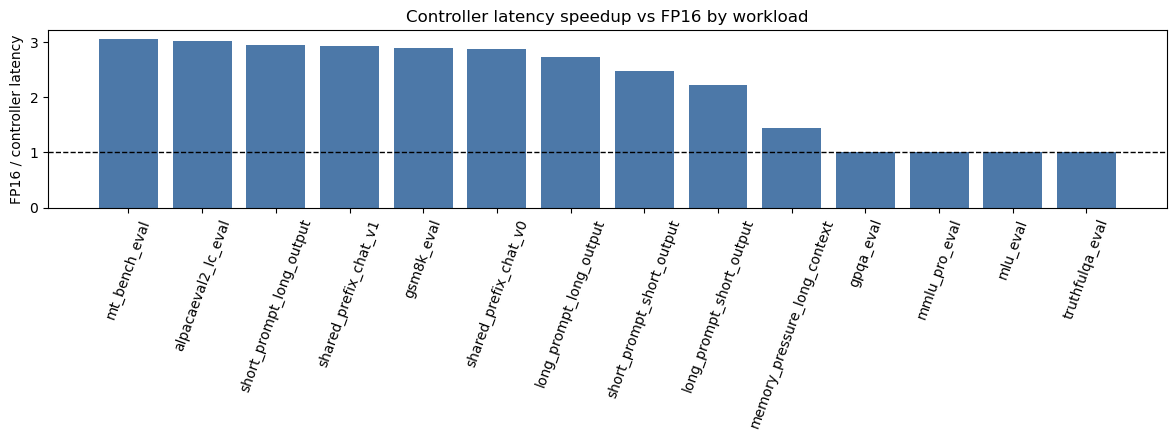

In [10]:
if not PLOTTING_AVAILABLE:
    print("Matplotlib not available. Skipping the latency chart.")
else:
    latency_plot_df = controller_perf_df.sort_values("latency_speedup", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.bar(latency_plot_df["workload_name"], latency_plot_df["latency_speedup"], color="#4c78a8")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Controller latency speedup vs FP16 by workload")
    ax.set_ylabel("FP16 / controller latency")
    ax.tick_params(axis="x", rotation=70)
    plt.tight_layout()
    plt.show()

This chart plots the controller's energy ratio against FP16 for every workload. Values below 1.0 mean the routed mode used less energy per token than the FP16 baseline on that workload.

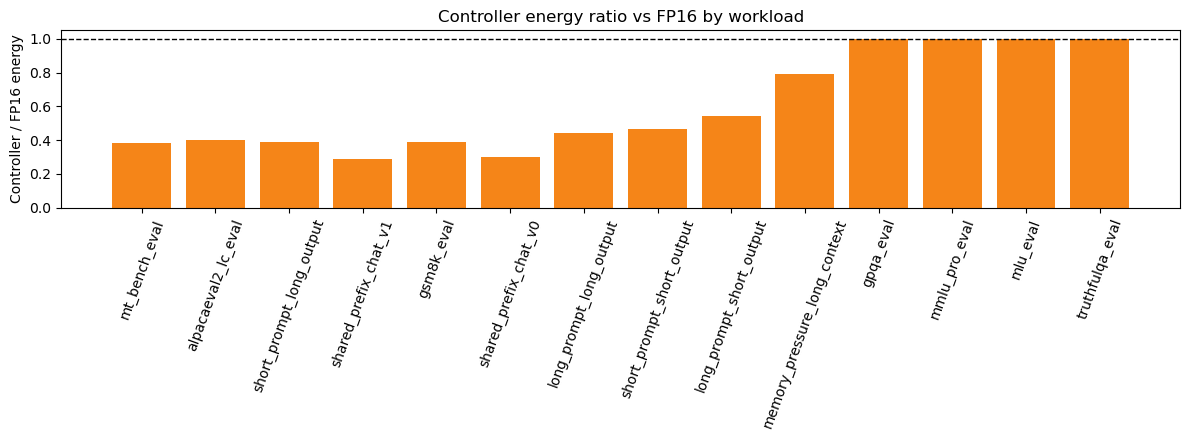

In [11]:
if not PLOTTING_AVAILABLE:
    print("Matplotlib not available. Skipping the energy chart.")
else:
    energy_plot_df = controller_perf_df.sort_values("latency_speedup", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.bar(energy_plot_df["workload_name"], energy_plot_df["energy_ratio"], color="#f58518")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Controller energy ratio vs FP16 by workload")
    ax.set_ylabel("Controller / FP16 energy")
    ax.tick_params(axis="x", rotation=70)
    plt.tight_layout()
    plt.show()

This chart counts how many workloads landed in each selected mode. It shows whether the controller spreads decisions across several branches or mostly collapses onto one mode.

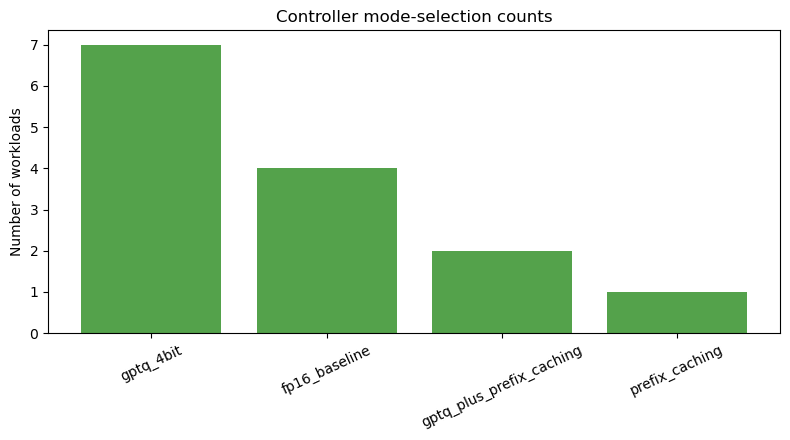

In [12]:
if not PLOTTING_AVAILABLE:
    print("Matplotlib not available. Skipping the mode-count chart.")
else:
    mode_count_plot_df = routing_branch_counts_df.sort_values("num_workloads", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(mode_count_plot_df["controller_selected_mode_name"], mode_count_plot_df["num_workloads"], color="#54a24b")
    ax.set_title("Controller mode-selection counts")
    ax.set_ylabel("Number of workloads")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()

## Headline numbers

This cell prints the high-level averages from the offline controller simulation. It gives one place to read the mean speedups, mean energy ratio, mean accuracy delta, and the pass or fail result for the quality threshold.

In [13]:
headline_numbers_df = pd.DataFrame([
    {
        "mean_latency_speedup": controller_perf_df["latency_speedup"].dropna().mean(),
        "mean_throughput_ratio": controller_perf_df["throughput_ratio"].dropna().mean(),
        "mean_energy_ratio": controller_perf_df["energy_ratio"].dropna().mean(),
        "mean_accuracy_delta_pts": mean_accuracy_delta_pts,
        "quality_threshold_result": "PASS" if accuracy_threshold_pass else "FAIL",
    }
])

print("Mean latency speedup:", round(float(headline_numbers_df.iloc[0]["mean_latency_speedup"]), 4))
print("Mean throughput ratio:", round(float(headline_numbers_df.iloc[0]["mean_throughput_ratio"]), 4))
print("Mean energy ratio:", round(float(headline_numbers_df.iloc[0]["mean_energy_ratio"]), 4))
print("Mean accuracy delta (controller - FP16):", round(float(headline_numbers_df.iloc[0]["mean_accuracy_delta_pts"]), 4))
print("Quality threshold:", headline_numbers_df.iloc[0]["quality_threshold_result"])

headline_numbers_df

Mean latency speedup: 2.183
Mean throughput ratio: 2.1539
Mean energy ratio: 0.5989
Mean accuracy delta (controller - FP16): -0.96
Quality threshold: PASS


,mean_latency_speedup,mean_throughput_ratio,mean_energy_ratio,mean_accuracy_delta_pts,quality_threshold_result
0,2.183001,2.153883,0.598882,-0.96,PASS


## Optional harness cross-check

If a real `dense_controller_results_*.json` sweep output exists in `results/raw`, this section compares the measured controller run to the offline simulation. If the file is not there yet, it prints a friendly message and leaves the section empty.

In [14]:
from pathlib import Path

raw_dir = Path("results/raw")
candidate_jsons = sorted(raw_dir.glob("dense_controller_results_*.json"))

if not candidate_jsons:
    print("No dense_controller_results_*.json file is available yet. This section will populate after the GPU sweep runs.")
else:
    from reporter import aggregate_results, load_results

    measured_json_path = candidate_jsons[-1]
    raw_results = load_results(measured_json_path)
    measured_aggregated = aggregate_results(raw_results)

    measured_controller_rows = []
    for agg in measured_aggregated.values():
        if agg.get("mode_name") != "controller_v1":
            continue
        measured_controller_rows.append({
            "workload_name": agg.get("workload_name"),
            "measured_controller_selected_mode_name": agg.get("controller_selected_mode_name"),
            "measured_controller_phase_label": agg.get("controller_phase_label"),
            "measured_controller_estimated_prefill_share_pct": (agg.get("controller_estimated_prefill_share_pct") or {}).get("mean"),
            "measured_total_latency_ms": (agg.get("total_latency_ms") or {}).get("mean"),
            "measured_tokens_per_second": (agg.get("tokens_per_second") or {}).get("mean"),
            "measured_energy_per_token_j": (agg.get("energy_per_token_j") or {}).get("mean"),
            "measured_peak_gpu_memory_mb": (agg.get("peak_gpu_memory_mb") or {}).get("mean"),
        })

    measured_controller_df = pd.DataFrame(measured_controller_rows)
    if measured_controller_df.empty:
        print(f"Loaded {measured_json_path}, but it does not contain aggregated controller_v1 rows yet.")
    else:
        cross_check_df = controller_perf_df.merge(
            measured_controller_df,
            on="workload_name",
            how="inner",
        )
        cross_check_df["latency_ratio_measured_over_simulated"] = (
            cross_check_df["measured_total_latency_ms"] / cross_check_df["total_latency_ms"]
        )
        cross_check_df["throughput_ratio_measured_over_simulated"] = (
            cross_check_df["measured_tokens_per_second"] / cross_check_df["tokens_per_second"]
        )
        cross_check_df["energy_ratio_measured_over_simulated"] = (
            cross_check_df["measured_energy_per_token_j"] / cross_check_df["energy_per_token_j"]
        )
        cross_check_df["memory_ratio_measured_over_simulated"] = (
            cross_check_df["measured_peak_gpu_memory_mb"] / cross_check_df["peak_gpu_memory_mb"]
        )

        print("Measured controller run used:", measured_json_path)
        display(cross_check_df[[
            "workload_name",
            "controller_selected_mode_name",
            "measured_controller_selected_mode_name",
            "latency_ratio_measured_over_simulated",
            "throughput_ratio_measured_over_simulated",
            "energy_ratio_measured_over_simulated",
            "memory_ratio_measured_over_simulated",
        ]].sort_values("workload_name").reset_index(drop=True))

No dense_controller_results_*.json file is available yet. This section will populate after the GPU sweep runs.
